In [22]:
# Imports
import sklearn as sk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as sp
import seaborn as sb

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [23]:
# Cargar dataset
countries = pd.read_csv('country_data.csv')
print(countries)
np.shape(countries)[1]
countries.columns

                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2       5.82    553  
1         4.49   

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

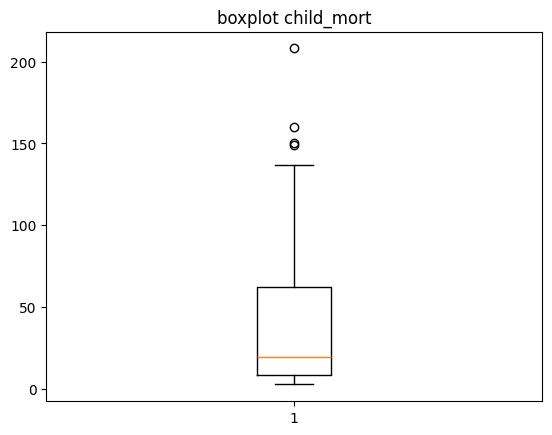

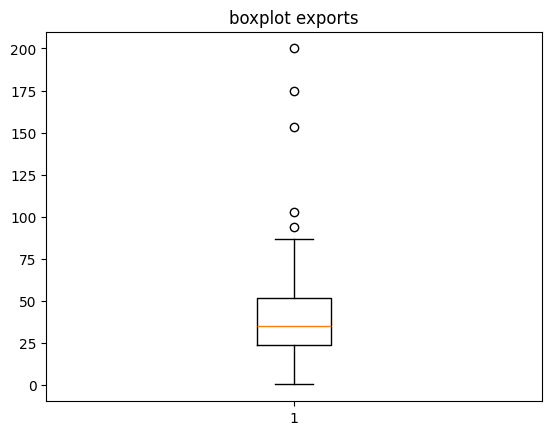

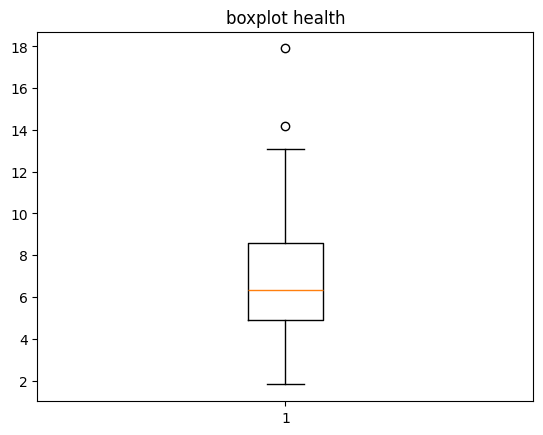

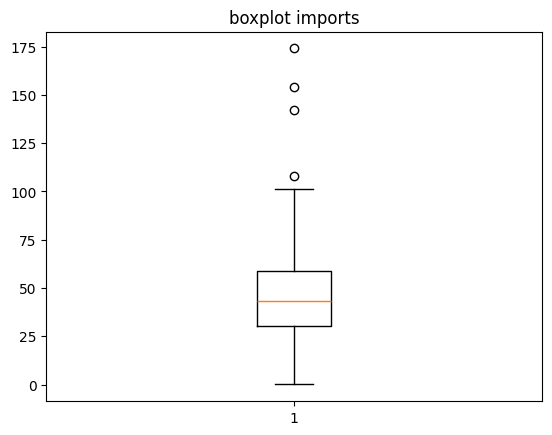

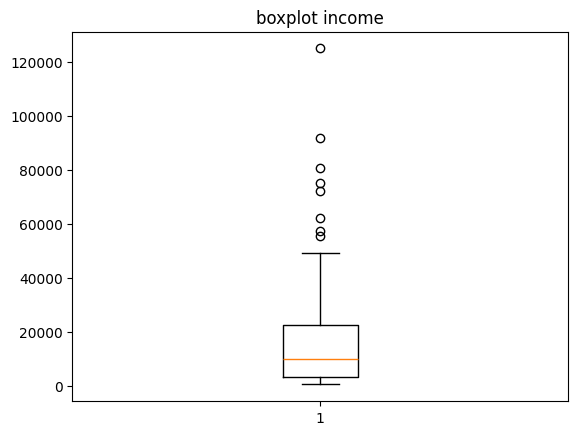

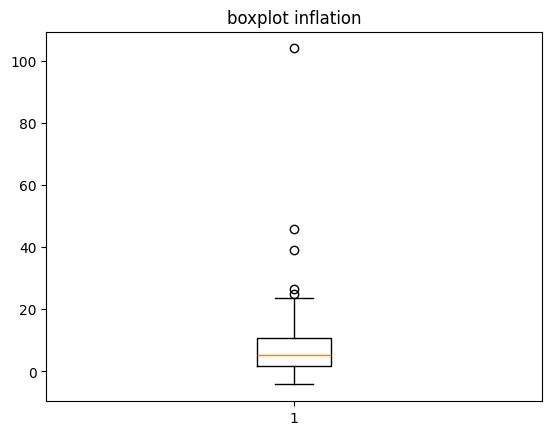

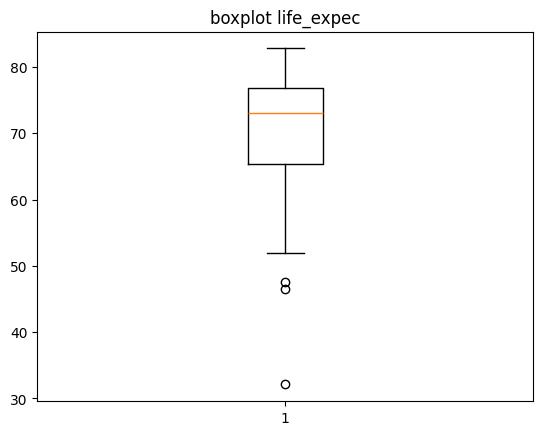

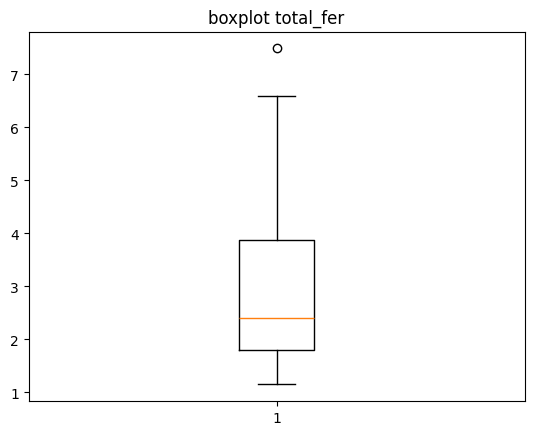

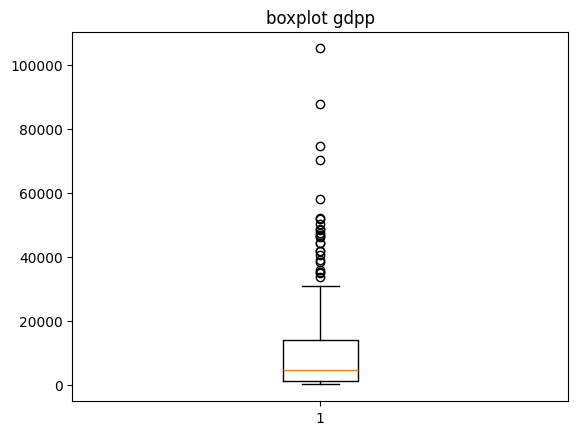

In [24]:
# Ejercicio 1
# Boxplots
for col in countries.columns[1:10]:
    plt.figure()
    plt.boxplot(countries[col])
    plt.title(f"boxplot {col}")
    plt.show()

In [ ]:
# Detectar anomalias
# A través de IQR
var = ['exports','imports','life_expec']

for col in var:
    IQR = sp.iqr(countries[col])
    Q1 = np.percentile(countries[col], 25)
    Q3 = np.percentile(countries[col], 75)
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f'\nAnalisis de anomalias en {col}')
    print(f"IQR: {IQR}, Range: [{lower_bound:.2f}, {upper_bound:.2f}]\n")

    for name, val in zip(countries['country'], countries[col]):
        if val < lower_bound or val > upper_bound:
            print(f"Pais: {name}, Valor: {val}")





Analisis de anomalias en exports
IQR: 27.549999999999994, Range: [-17.52, 92.67]

Pais: Ireland, Valor: 103.0
Pais: Luxembourg, Valor: 175.0
Pais: Malta, Valor: 153.0
Pais: Seychelles, Valor: 93.8
Pais: Singapore, Valor: 200.0

Analisis de anomalias en imports
IQR: 28.55, Range: [-12.63, 101.58]

Pais: Luxembourg, Valor: 142.0
Pais: Malta, Valor: 154.0
Pais: Seychelles, Valor: 108.0
Pais: Singapore, Valor: 174.0

Analisis de anomalias en life_expec
IQR: 11.5, Range: [48.05, 94.05]

Pais: Central African Republic, Valor: 47.5
Pais: Haiti, Valor: 32.1
Pais: Lesotho, Valor: 46.5


Para la variable de exportaciones, se observa que Irlanda, Luxemburgo, Malta, Seychelles y Singapur son anomalías que están por encima de los valores normales.

En cuanto a la variable de importaciones, los mismos países mencionados anteriormente (excepto Irlanda) resultan ser anomalías. Por lo tanto, parece que los países pequeños se encuentran por encima del nivel normal en cuanto a importaciones y exportaciones.

Finalmente, respecto a la esperanza de vida, encontramos tres países por debajo del nivel normal: Haití, República Centroafricana y Lesoto.

Se nota que los países pequeños exportan e importan mucho. Es de suponer que las Seychelles necesitan importar la mayoría de los productos, aunque se desconoce qué exportan. Es posible que su condición de 'paraíso fiscal' contribuya al cálculo final. Por último, tres de los países más pobres del mundo, con situaciones sociales complejas, tienen una esperanza de vida realmente baja. Una media de solo 32 años de vida es increíblemente poca.

            child_mort   exports    health   imports    income  inflation  \
child_mort    1.000000 -0.318093 -0.200402 -0.127211 -0.524315   0.288276   
exports      -0.318093  1.000000 -0.114408  0.737381  0.516784  -0.107294   
health       -0.200402 -0.114408  1.000000  0.095717  0.129579  -0.255376   
imports      -0.127211  0.737381  0.095717  1.000000  0.122406  -0.246994   
income       -0.524315  0.516784  0.129579  0.122406  1.000000  -0.147756   
inflation     0.288276 -0.107294 -0.255376 -0.246994 -0.147756   1.000000   
life_expec   -0.886676  0.316313  0.210692  0.054391  0.611962  -0.239705   
total_fer     0.848478 -0.320011 -0.196674 -0.159048 -0.501840   0.316921   
gdpp         -0.483032  0.418725  0.345966  0.115498  0.895571  -0.221631   

            life_expec  total_fer      gdpp  
child_mort   -0.886676   0.848478 -0.483032  
exports       0.316313  -0.320011  0.418725  
health        0.210692  -0.196674  0.345966  
imports       0.054391  -0.159048  0.115498  

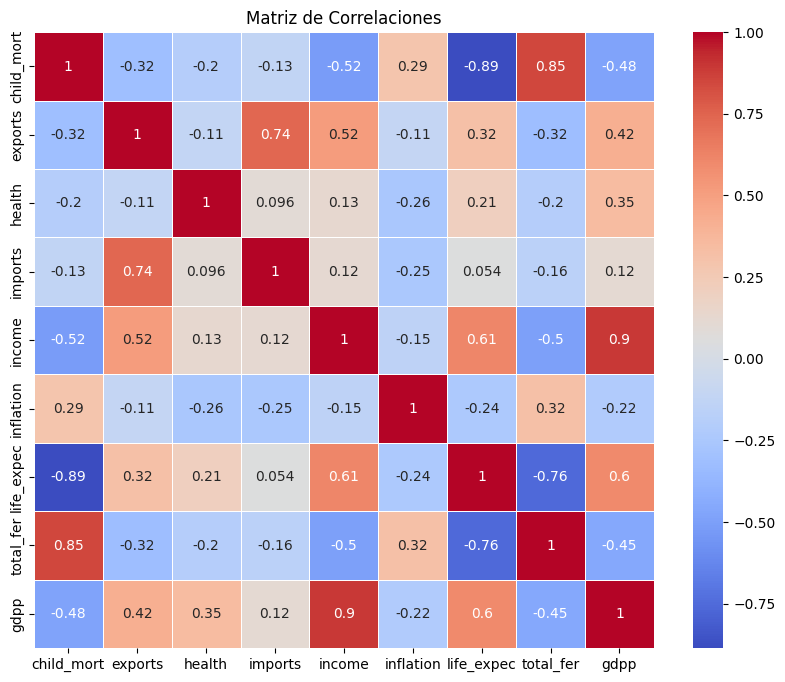

In [27]:
# Matriz de coorelaciones
dataframe = countries.iloc[:, 0:10]
correlation_matrix = dataframe.iloc[:, 1:10].corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlaciones')
plt.show()


Se nota que los indicadores económicos están bien vinculados entre sí y, del mismo modo, los indicadores de salud. Por supuesto, income tiene una correlación de 0,9 con gdpp y, por otro lado, life_expec está muy correlacionado negativamente con child_mort. Se nota también que imports está prácticamente descorrelacionado de health.

Por último, me parece interesante que los países que exportan mucho también importan mucho; me imagino que esto generalmente está relacionado también con el tamaño del país, aunque esto no se cumple debido a las anomalías que vimos anteriormente. Además, es interesante notar las relaciones entre variables sociales y económicas. Por ejemplo, life_expec y gdpp están bastante relacionadas; lo mismo pasa entre income y life_expec o child_mort, lo cual es signo de la relación real y significativa de cómo mejoran las condiciones de salud en los países más ricos.

In [28]:
# Estandardizar datos

dataframe[dataframe.columns[1:10]] = dataframe[dataframe.columns[1:10]].astype(float)

dataframe[dataframe.columns[1:10]] = sk.preprocessing.StandardScaler().fit_transform(dataframe[dataframe.columns[1:10]])

print(np.mean(dataframe.iloc[:,1]))
print(np.std(dataframe.iloc[:,1]))
print(dataframe)

-3.722903555629267e-17
1.0
                 country  child_mort   exports    health   imports    income  \
0            Afghanistan    1.291532 -1.138280  0.279088 -0.082455 -0.808245   
1                Albania   -0.538949 -0.479658 -0.097016  0.070837 -0.375369   
2                Algeria   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   
3                 Angola    2.007808  0.775381 -1.448071 -0.165315 -0.585043   
4    Antigua and Barbuda   -0.695634  0.160668 -0.286894  0.497568  0.101732   
..                   ...         ...       ...       ...       ...       ...   
162              Vanuatu   -0.225578  0.200917 -0.571711  0.240700 -0.738527   
163            Venezuela   -0.526514 -0.461363 -0.695862 -1.213499 -0.033542   
164              Vietnam   -0.372315  1.130305  0.008877  1.380030 -0.658404   
165                Yemen    0.448417 -0.406478 -0.597272 -0.517472 -0.658924   
166               Zambia    1.114951 -0.150348 -0.338015 -0.662477 -0.721358   

     inflati

1503.0000000000002
1063.4825600467798
831.5351582151586
751.1915754969666
620.3621532663785
563.5602864947639
496.2696004780955
490.8008362745423
455.0170220483582
433.53844084848174


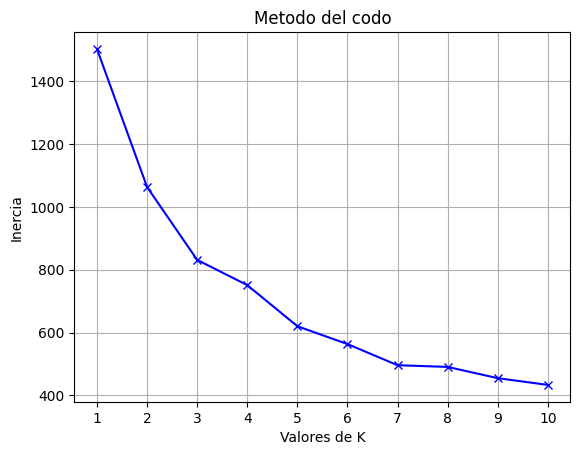

In [29]:
# Ejercicio 2
from sklearn.cluster import KMeans

k_n = [1,2,3,4,5,6,7,8,9,10]
inercias = []
for k in k_n:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(dataframe.iloc[:, 1:10])
    print(kmeans.inertia_)
    inercias.append(kmeans.inertia_)


plt.plot(range(1, 11), inercias, 'bx-')
plt.grid()
plt.xlabel('Valores de K')
plt.xticks(range(1, 11), range(1, 11))
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.show()

Basándome exclusivamente en el método del codo, sería difícil elegir entre 3, 4 y 5 clústeres, porque la caída del valor de la inercia entre 3 y 4 no es tan grande como las anteriores. Por lo tanto, para lograr una mejor elección del valor, se echa un vistazo a los clústeres asignados a cada país para ambos valores de k.

In [ ]:
n_clusters = 3
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters = hc.fit_predict(dataframe.iloc[:, 1:10])

for country, cluster in zip(dataframe.iloc[:, 0], clusters):
    print(f"{country}: cluster {cluster}")

Afghanistan: cluster 2
Albania: cluster 1
Algeria: cluster 1
Angola: cluster 1
Antigua and Barbuda: cluster 1
Argentina: cluster 1
Armenia: cluster 1
Australia: cluster 0
Austria: cluster 0
Azerbaijan: cluster 1
Bahamas: cluster 1
Bahrain: cluster 0
Bangladesh: cluster 1
Barbados: cluster 1
Belarus: cluster 1
Belgium: cluster 0
Belize: cluster 1
Benin: cluster 2
Bhutan: cluster 1
Bolivia: cluster 1
Bosnia and Herzegovina: cluster 1
Botswana: cluster 1
Brazil: cluster 1
Brunei: cluster 0
Bulgaria: cluster 1
Burkina Faso: cluster 2
Burundi: cluster 2
Cambodia: cluster 1
Cameroon: cluster 2
Canada: cluster 0
Cape Verde: cluster 1
Central African Republic: cluster 2
Chad: cluster 2
Chile: cluster 1
China: cluster 1
Colombia: cluster 1
Comoros: cluster 2
Congo, Dem. Rep.: cluster 2
Congo, Rep.: cluster 1
Costa Rica: cluster 1
Cote d'Ivoire: cluster 2
Croatia: cluster 1
Cyprus: cluster 1
Czech Republic: cluster 1
Denmark: cluster 0
Dominican Republic: cluster 1
Ecuador: cluster 1
Egypt: clus

In [ ]:
n_clusters = 4 
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters = hc.fit_predict(dataframe.iloc[:, 1:10])

for country, cluster in zip(dataframe.iloc[:, 0], clusters):
    print(f"{country}: cluster {cluster}")

Afghanistan: cluster 2
Albania: cluster 0
Algeria: cluster 0
Angola: cluster 0
Antigua and Barbuda: cluster 0
Argentina: cluster 0
Armenia: cluster 0
Australia: cluster 1
Austria: cluster 1
Azerbaijan: cluster 0
Bahamas: cluster 0
Bahrain: cluster 1
Bangladesh: cluster 0
Barbados: cluster 0
Belarus: cluster 0
Belgium: cluster 1
Belize: cluster 0
Benin: cluster 2
Bhutan: cluster 0
Bolivia: cluster 0
Bosnia and Herzegovina: cluster 0
Botswana: cluster 0
Brazil: cluster 0
Brunei: cluster 1
Bulgaria: cluster 0
Burkina Faso: cluster 2
Burundi: cluster 2
Cambodia: cluster 0
Cameroon: cluster 2
Canada: cluster 1
Cape Verde: cluster 0
Central African Republic: cluster 2
Chad: cluster 2
Chile: cluster 0
China: cluster 0
Colombia: cluster 0
Comoros: cluster 2
Congo, Dem. Rep.: cluster 2
Congo, Rep.: cluster 0
Costa Rica: cluster 0
Cote d'Ivoire: cluster 2
Croatia: cluster 0
Cyprus: cluster 0
Czech Republic: cluster 0
Denmark: cluster 1
Dominican Republic: cluster 0
Ecuador: cluster 0
Egypt: clus

In [36]:
n_clusters = 5
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters = hc.fit_predict(dataframe.iloc[:, 1:10])

for country, cluster in zip(dataframe.iloc[:, 0], clusters):
    print(f"{country}: cluster {cluster}")

Afghanistan: cluster 2
Albania: cluster 4
Algeria: cluster 0
Angola: cluster 0
Antigua and Barbuda: cluster 4
Argentina: cluster 0
Armenia: cluster 4
Australia: cluster 1
Austria: cluster 1
Azerbaijan: cluster 4
Bahamas: cluster 4
Bahrain: cluster 1
Bangladesh: cluster 0
Barbados: cluster 4
Belarus: cluster 4
Belgium: cluster 1
Belize: cluster 4
Benin: cluster 2
Bhutan: cluster 4
Bolivia: cluster 0
Bosnia and Herzegovina: cluster 4
Botswana: cluster 4
Brazil: cluster 0
Brunei: cluster 1
Bulgaria: cluster 4
Burkina Faso: cluster 2
Burundi: cluster 2
Cambodia: cluster 4
Cameroon: cluster 2
Canada: cluster 1
Cape Verde: cluster 4
Central African Republic: cluster 2
Chad: cluster 2
Chile: cluster 0
China: cluster 0
Colombia: cluster 0
Comoros: cluster 2
Congo, Dem. Rep.: cluster 2
Congo, Rep.: cluster 0
Costa Rica: cluster 4
Cote d'Ivoire: cluster 2
Croatia: cluster 4
Cyprus: cluster 4
Czech Republic: cluster 4
Denmark: cluster 1
Dominican Republic: cluster 0
Ecuador: cluster 0
Egypt: clus

Observando los clústeres asignados, para mí es mejor elegir 3 en lugar de 4 o 5. Esto se debe a que me parece que, al dividir los países en 4 o 5, algunas asignaciones resultan más mezcladas y sorprendentes. Por ejemplo, hay algunos países europeos (como la República Checa) en el mismo clúster que países mucho más pobres. Con este método de clustering, hemos elegido agrupamientos que dividen a los países por diversas condiciones sociales. La condición económica es muy importante, pero también lo son los indicadores de calidad de vida.

Lo que sucede es que, por ejemplo, países grandes y ricos (ej. Rusia y China) no se clasifican del mismo modo que países igual de ricos pero con condiciones de vida diferentes. Con 3 clústeres, dividiremos los países en niveles que podríamos definir como:

    Mejor (1)

    Medio (0)

    Peor (2)

Algo curioso es que Libia se encuentra entre los países con una condición general mejor.

Para terminar este comentario, diría que el método del codo respalda la elección de 3 clústeres. Esta estructura permite diferenciar claramente entre economías desarrolladas, economías en vías de desarrollo y países en situación de vulnerabilidad social y económica.

91     Luxembourg
98          Malta
133     Singapore
123         Qatar
115          Oman
          ...    
2         Algeria
79     Kazakhstan
5       Argentina
71           Iran
125        Russia
Name: country, Length: 167, dtype: str


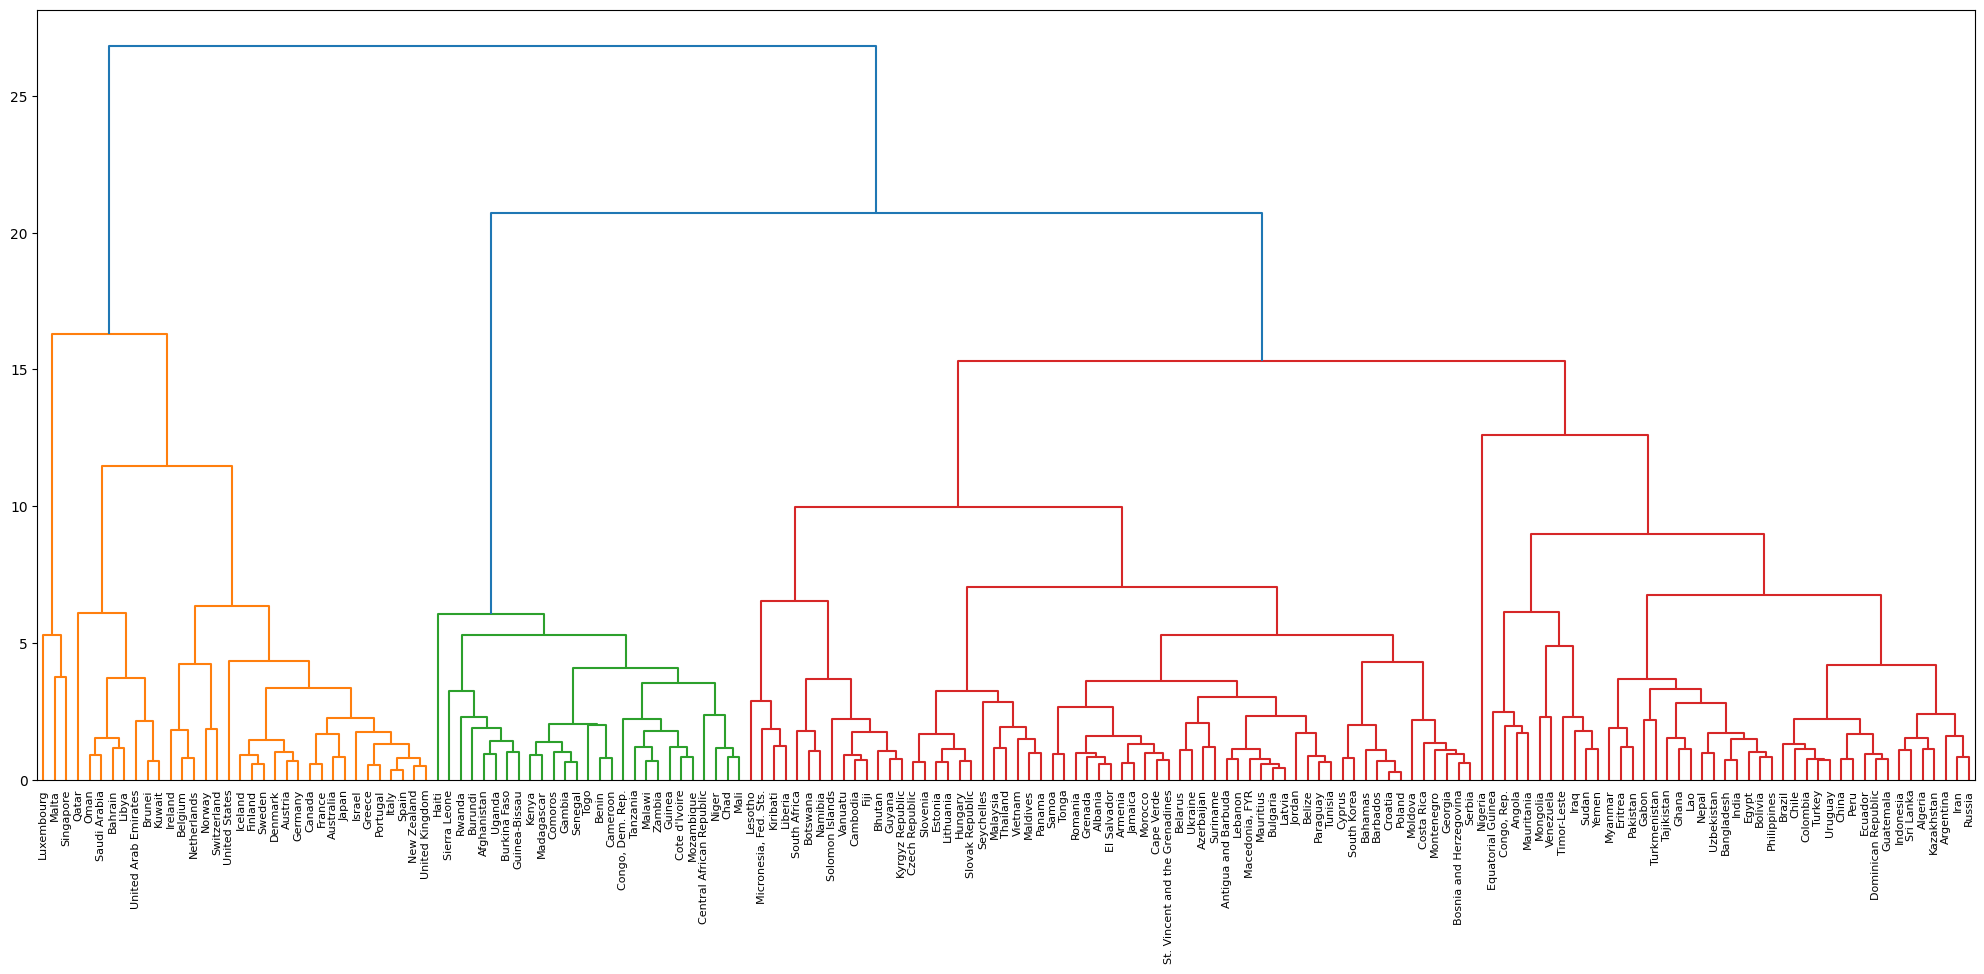

In [ ]:
# Clustering aglomerativo

from scipy.cluster.hierarchy import dendrogram, linkage

alfa = dataframe.sort_values(by=dataframe.columns[0], ascending=True)

method = "ward"
Z = linkage(alfa.iloc[:, 1:10], method)
plt.figure(figsize=(25, 10))

dendrograma = dendrogram(
    Z,
    leaf_rotation=90., 
    no_labels=False,
    labels = alfa.iloc[:, 0].values,  
    leaf_font_size=8., 
    
)

print(alfa.iloc[dendrograma['leaves'],0])

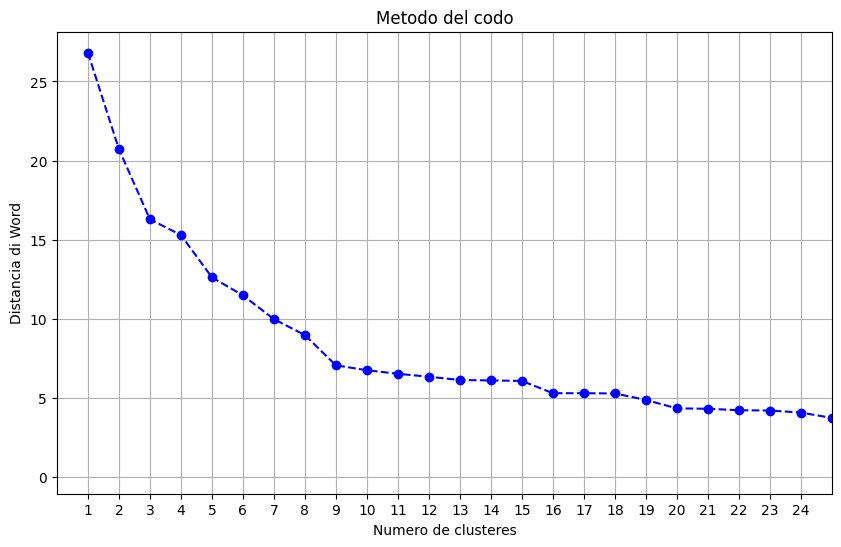

In [ ]:
# Metodo del codo vs distancia de Ward

# Distancias de fusion
distancias = Z[:, 2]

distancias_rev = distancias[::-1]
idxs = np.arange(1, len(distancias) + 1)

plt.figure(figsize=(10, 6))
plt.plot(idxs, distancias_rev, marker='o', linestyle='--', color='b')

plt.title('Metodo del codo')
plt.xlabel('Numero de clusteres')
plt.ylabel('Distancia di Word')

plt.xlim(0, 25) # Limitato a 50 para mejor visualizacion
plt.xticks(range(1, 25), range(1, 25))
plt.grid(True)
plt.show()

Basándome en el método del codo, yo pondría el nivel de corte del dendrograma en 9, porque a este nivel se nota el «codo definitivo» de la curva.

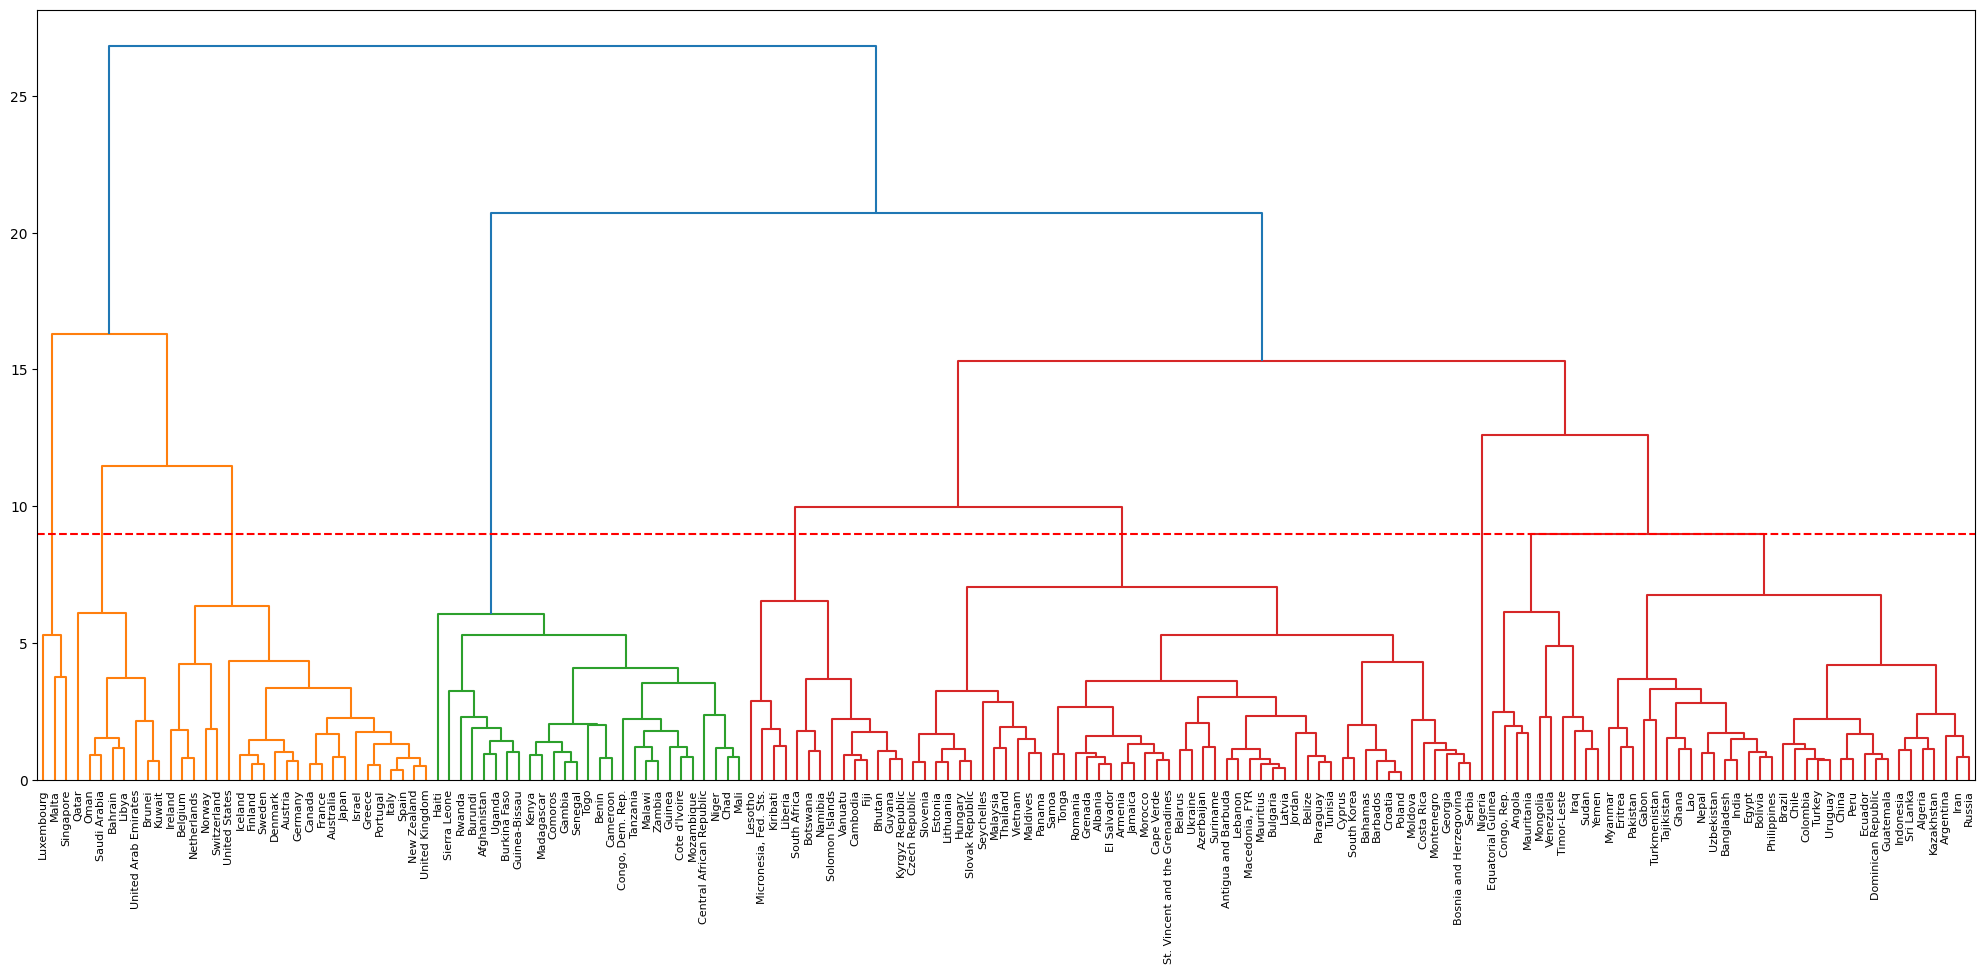

In [ ]:
plt.figure(figsize=(25, 10))

dendrograma = dendrogram(
    Z,
    leaf_rotation=90., 
    no_labels=False,
    labels = alfa.iloc[:, 0].values,  
    leaf_font_size=8., 
    
)
plt.axhline(y=9, color='red', linestyle='--')


Se nota una evidente distinción entre los países más desarrollados (países europeos, de la península arábica, Norteamérica y los países más ricos de Oceanía) en naranja a la izquierda, que se unen con los otros países solo al final del dendrograma. Entre estos primeros países están también los estados más pequeños (los primeros tres), que se unen con más retraso que los otros. Otra vez, resulta muy raro en este clúster la presencia de Libia, que me suena bastante extraño en el grupo de los 'mejores'. Algo que, por el contrario, no me sorprende es que los PIGS (Portugal, Italia, Grecia y España) se confirman como similares entre ellos y se unen entre los primeros grupos, aunque Italia y España también se unen con Nueva Zelanda y el Reino Unido. También los países escandinavos se unen pronto.

Inmediatamente a la derecha está el grupo que se encuentra en la situación realmente más alejada de los primeros países. En verde están los países más pobres del mundo, a excepción de Haití, que entre estos es el más alejado. Luego hay grupos que comprenden los países más pobres de la Unión Europea y otros países del Cercano Oriente, América del Sur, Asia y África. Este megaclúster rojo comprende varios países con condiciones económicas medias. Esto confirma también que 3 clústeres es un número correcto, como en el caso de K-Means.

Algo bastante único es el caso de Nigeria, que es el país más singular, de hecho, porque es el último país en unirse a los otros. En este caso, se unirá después de nuestro nivel de corte y será un clúster en sí mismo con nuestra clasificación. Me imagino a Nigeria a medio camino entre los países pobres y los países económicamente desarrollados que, sin embargo, se encuentran en condiciones sociales peores.

Con 9 clústeres tenemos:

    Países pequeños.

    Países de la península arábica, Libia y Brunéi.

    Países más desarrollados de Europa.

    Países más pobres.

    Países medio-pobres.

    Países medios con condiciones sociales medias.

    Nigeria.

    Países más ricos pero con condiciones sociales peores.

En conclusión, se observa una consistencia entre K-Means y el clustering jerárquico.